In [169]:
import numpy as np 
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [170]:
df = pd.read_csv("files/apple_quality.csv")

In [171]:
df.head(10)

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
5,5.0,-3.425400,-1.409082,-1.913511,-0.555775,-3.853071,1.914616,-2.981523169,bad
6,6.0,1.331606,1.635956,0.875974,-1.677798,3.106344,-1.847417,2.414170509,good
7,7.0,-1.995462,-0.428958,1.530644,-0.742972,0.158834,0.974438,-1.470125066,good
8,8.0,-3.867632,-3.734514,0.986429,-1.207655,2.292873,4.080921,-4.871904758,bad
9,9.0,-0.727983,-0.442820,-4.092223,0.597513,0.393714,1.620857,2.185607723,bad


In [172]:
df.describe()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1999.500000,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277
std,1154.844867,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427
min,0.000000,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599
25%,999.750000,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677
50%,1999.500000,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445
75%,2999.250000,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212
max,3999.000000,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837


In [173]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB
None


In [174]:
df = df.drop("A_id", axis=1)

In [175]:
df.iloc[4000:]

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
4000,NaN,NaN,NaN,NaN,NaN,NaN,Created_by_Nidula_Elgiriyewithana,NaN


In [176]:
df = df.iloc[:4000]
# df = df.dropna()

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   object 
 7   Quality      4000 non-null   object 
dtypes: float64(6), object(2)
memory usage: 250.1+ KB
None


In [177]:
df['Quality'] = df['Quality'].map({'good': 1, 'bad': 0})

In [178]:
X = df.drop("Quality", axis=1)
y = df["Quality"]

In [179]:
df[df.isnull().any(axis=1)]

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality


In [180]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import plot_tree

X_train, _X, y_train, _y = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(_X, _y, train_size=0.5, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [181]:
depth_train_list = []
depth_val_list = []

max_depth_list = np.linspace(1,30,20).astype(int)
for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    predictions_train = model.predict(X_train_scaled)
    predictions_val = model.predict(X_val_scaled)
    
    accuracy_score_train = accuracy_score(y_train, predictions_train)
    accuracy_score_val = accuracy_score(y_val, predictions_val)
    
    depth_train_list.append(accuracy_score_train)
    depth_val_list.append(accuracy_score_val)

Text(0, 0.5, 'Accuracy')

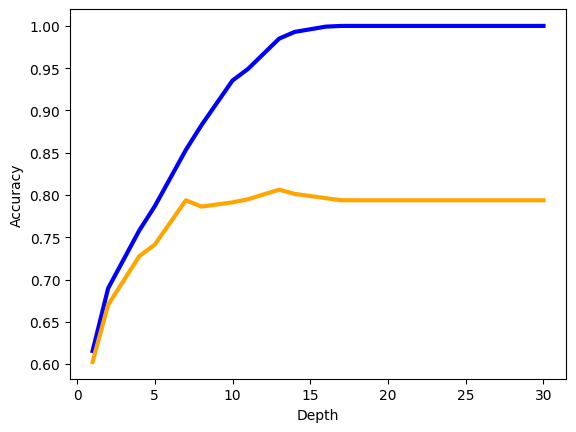

In [182]:
plt.plot(max_depth_list, depth_train_list, color = 'blue', linewidth = 3)
plt.plot(max_depth_list, depth_val_list, color = 'orange', linewidth = 3)
plt.xlabel('Depth')
plt.ylabel('Accuracy')

In [183]:
samples_train_list = []
samples_val_list = []

min_samples_split_list = np.linspace(2,300, 20).astype(int)
for min_samples_split in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split=min_samples_split, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    predictions_train = model.predict(X_train_scaled)
    predictions_val = model.predict(X_val_scaled)
    
    accuracy_score_train = accuracy_score(y_train, predictions_train)
    accuracy_score_val = accuracy_score(y_val, predictions_val)
    
    samples_train_list.append(accuracy_score_train)
    samples_val_list.append(accuracy_score_val)

Text(0, 0.5, 'Accuracy')

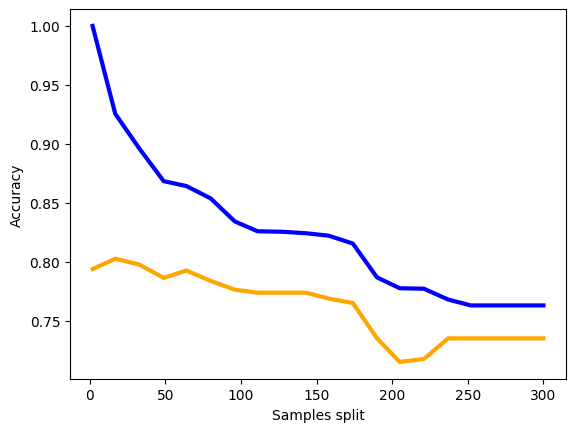

In [184]:
plt.plot(min_samples_split_list, samples_train_list, color = 'blue', linewidth = 3)
plt.plot(min_samples_split_list, samples_val_list, color = 'orange', linewidth = 3)
plt.xlabel('Samples split')
plt.ylabel('Accuracy')

In [185]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=8,random_state=42)
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=8, random_state=42)

In [186]:
y_pred_dt = dt_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.77125
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       397
           1       0.80      0.73      0.76       403

    accuracy                           0.77       800
   macro avg       0.77      0.77      0.77       800
weighted avg       0.77      0.77      0.77       800



In [187]:
y_pred_dt = dt_model.predict(X_val_scaled)

print(f"Accuracy: {accuracy_score(y_val, y_pred_dt)}")
print(classification_report(y_val, y_pred_dt))

Accuracy: 0.78625
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       393
           1       0.82      0.75      0.78       407

    accuracy                           0.79       800
   macro avg       0.79      0.79      0.79       800
weighted avg       0.79      0.79      0.79       800



In [188]:
def split_dataset(X, y, feature_index, threshold):
    left = X[:, feature_index] <= threshold
    right = X[:, feature_index] > threshold
    return (X[left], y[left]), (X[right], y[right])

def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return 1.0 - np.sum(probabilities**2)

def best_split(X, y):
    m, n = X.shape
    best_gini = 1
    best_index = None 
    best_threshold = None

    for feature_index in range(n):
        thresholds = np.unique(X[:, feature_index])
        for threshold in thresholds:
            (left_X, left_y), (right_X, right_y) = split_dataset(X, y, feature_index, threshold)
            if len(left_y) == 0 or len(right_y) == 0:
                continue

            p_left = len(left_y) / len(y)
            p_right = len(right_y) / len(y)
            gini_split = p_left * gini(left_y) + p_right * gini(right_y)

            if gini_split < best_gini:
                best_gini = gini_split
                best_index = feature_index
                best_threshold = threshold

    return best_index, best_threshold

class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def fit(self, X, y):
        self.n_features = X.shape[1]
        self.tree = self._grow_tree(X, y)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict(inputs) for inputs in X])

    def _grow_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        if (depth >= self.max_depth or num_labels == 1 or
            num_samples < self.min_samples_split):
            return Node(value=self._most_common_label(y))

        feature_index, threshold = best_split(X, y)
        if feature_index is None:
            return Node(value=self._most_common_label(y))

        (left_X, left_y), (right_X, right_y) = split_dataset(X, y, feature_index, threshold)
        left = self._grow_tree(left_X, left_y, depth + 1)
        right = self._grow_tree(right_X, right_y, depth + 1)
        return Node(feature_index, threshold, left, right)

    def _predict(self, inputs):
        node = self.tree
        while node.value is None:
            if inputs[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

    def _most_common_label(self, y):
        unique, counts = np.unique(y, return_counts=True)
        most_common = unique[np.argmax(counts)] # Если 50 на 50, какой выберется.
        return most_common
    
    def print_tree(self):
        self._print_tree(self.tree)

    def _print_tree(self, node, depth=0):
        if node.value is not None:
            print("  " * depth + f"Leaf: {node.value}")
        else:
            print("  " * depth + f"Feature {node.feature_index} <= {node.threshold}")
            print("  " * (depth + 1) + "Left:")
            self._print_tree(node.left, depth + 1)
            print("  " * (depth + 1) + "Right:")
            self._print_tree(node.right, depth + 1)

class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [189]:
mdt_model = DecisionTree(max_depth=8, min_samples_split=2)
mdt_model.fit(X_train_scaled, y_train)

In [190]:
mdt_model.print_tree()

Feature 4 <= -0.47576858076879264
  Left:
  Feature 0 <= -0.044203600174530594
    Left:
    Feature 3 <= -1.444515363410677
      Left:
      Feature 5 <= 1.2009923229667254
        Left:
        Feature 1 <= -2.1362452085998718
          Left:
          Leaf: 0
          Right:
          Leaf: 1
        Right:
        Feature 0 <= -0.22503709928782895
          Left:
          Leaf: 0
          Right:
          Leaf: 1
      Right:
      Feature 5 <= -1.0029616187929657
        Left:
        Feature 2 <= 0.37377980444198805
          Left:
          Feature 5 <= -1.5761073860440828
            Left:
            Leaf: 1
            Right:
            Feature 6 <= -0.3235029700335267
              Left:
              Feature 1 <= -0.7821857473854111
                Left:
                Leaf: 1
                Right:
                Leaf: 0
              Right:
              Leaf: 1
          Right:
          Feature 3 <= 0.21077260340893184
            Left:
            Leaf: 1
      

In [191]:
y_pred = mdt_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))


Accuracy: 0.77125
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       397
           1       0.81      0.72      0.76       403

    accuracy                           0.77       800
   macro avg       0.77      0.77      0.77       800
weighted avg       0.77      0.77      0.77       800



In [192]:
y_pred_dt = mdt_model.predict(X_val_scaled)

print(f"Accuracy: {accuracy_score(y_val, y_pred_dt)}")
print(classification_report(y_val, y_pred_dt))

Accuracy: 0.78625
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       393
           1       0.82      0.74      0.78       407

    accuracy                           0.79       800
   macro avg       0.79      0.79      0.79       800
weighted avg       0.79      0.79      0.79       800



In [200]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class GradientBoosting:
    def __init__(self, n_estimators=3, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        self.y_pred = np.zeros(y.shape)
        
        residuals = y - sigmoid(self.y_pred)
        
        for _ in range(self.n_estimators):
            tree = DecisionTree(max_depth=self.max_depth)
            tree.fit(X, residuals)
            self.trees.append(tree)
            
            tree_predictions = tree.predict(X)
            tree_predictions = np.clip(tree_predictions, 0, 1)
            
            self.y_pred += self.learning_rate * tree_predictions
            residuals = y - sigmoid(self.y_pred)
    
    def predict(self, X):
        predictions = np.zeros(X.shape[0])
        for tree in self.trees:
            tree_predictions = tree.predict(X)
            tree_predictions = np.clip(tree_predictions, 0, 1)
            predictions += self.learning_rate * tree_predictions
        return (sigmoid(predictions) > 0.5).astype(int)

In [201]:
mgb_model = GradientBoosting()
mgb_model.fit(X_train_scaled, y_train)

In [195]:
y_pred = mgb_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.71
              precision    recall  f1-score   support

           0       0.80      0.56      0.66       397
           1       0.66      0.86      0.75       403

    accuracy                           0.71       800
   macro avg       0.73      0.71      0.70       800
weighted avg       0.73      0.71      0.70       800



In [203]:
y_pred = mgb_model.predict(X_val_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.4775
              precision    recall  f1-score   support

           0       0.46      0.29      0.36       397
           1       0.49      0.66      0.56       403

    accuracy                           0.48       800
   macro avg       0.47      0.48      0.46       800
weighted avg       0.47      0.48      0.46       800



In [239]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(max_depth=8, min_samples_split=20,random_state=5)
gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(max_depth=8, min_samples_split=20, random_state=5)

In [240]:
y_pred = gb_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8675
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       397
           1       0.87      0.86      0.87       403

    accuracy                           0.87       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.87      0.87      0.87       800



In [241]:
y_pred = gb_model.predict(X_val_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.5075
              precision    recall  f1-score   support

           0       0.50      0.50      0.50       397
           1       0.51      0.51      0.51       403

    accuracy                           0.51       800
   macro avg       0.51      0.51      0.51       800
weighted avg       0.51      0.51      0.51       800

